# Tarea 01 - Modelos Lineales

## Integrantes

* Centeno Amado Eduardo
* Orozpe Frias Erick Adrian
* Pineda Gaona Maricruz
* Rodriguez Teodores Armando
* Velasco Martell Dayra

## Instrucciones

## Práctica

![img3](Imgs/T01_Inst3.png)

# Librerías

In [1]:
#General
import pandas as pd
import numpy as np
import re #RegEx

#Graficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#Valores atipicos
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.mcd import MCD

In [2]:
from pandas.api.types import CategoricalDtype

In [3]:
#Codificadores
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Métodos Lineales
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

#Escaladores
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

#Busqueda de hiper-parametros, train test y CV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split

#Performance
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error, r2_score

# Funciones

In [4]:
def is_na_df(df):
    #Establecemos el resumen de NAs por columna
    na_summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "columna", 0: "n_missing"})
    )

    #Tomamos totales y prporciones
    na_summary["total"] = len(df)
    na_summary["prop_missing"] = na_summary["n_missing"] / na_summary["total"]
    na_summary["prop_original"] = 1 - na_summary["prop_missing"]

    #Filtramos solo columnas con al menos 1 NA
    na_summary = na_summary[na_summary["n_missing"] > 0].reset_index(drop=True)

    #Agregamos fila resumen global
    total_missing = df.isna().sum().sum()
    total_elements = df.size
    prop_missing_global = total_missing / total_elements
    prop_original_global = 1 - prop_missing_global

    resumen = pd.DataFrame({
        "columna": ["TOTAL"],
        "n_missing": [total_missing],
        "total": [total_elements],
        "prop_missing": [prop_missing_global],
        "prop_original": [prop_original_global]
    })

    na_summary = pd.concat([na_summary, resumen], ignore_index=True)

    return na_summary

In [5]:
#Definimos un objeto para graficar
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{var} - Boxplot", f"{var} - Histograma"))

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#008080"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             marker_color="#00a77d", nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        for var in self.cat_vars:
            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            fig = go.Figure(
                data=[go.Pie(labels=labels, values=values, textinfo='percent+label')]
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=500)
            fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self, color, values: bool = False):
        corr_matrix = self.df[self.num_vars].corr()

        if values:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color,
                text=corr_matrix.round(1).values,      # valores de correlación con 1 decimal
                texttemplate="%{text}",                # mostrar texto en cada celda
                textfont={"size":10, "color":"black"}  # estilo de fuente
                ))
        else:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color
                ))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [6]:
def detect_outliers_iforest(df, n_estimators=100, contamination=0.01, random_state=1989):
    model = IForest(n_estimators=n_estimators, contamination=contamination, random_state=random_state)
    model.fit(df.values)
    preds = model.predict(df.values)
    return df[preds == 1]

# Práctica 01 - Precio de un diamante 

Modelos lineales para la predicción del valor de un diamante de acuerdo a sus atributos.

## Carga de Datos

In [7]:
diamonds = pd.read_csv(r'https://raw.githubusercontent.com/Wsm-erick/Diplomado/refs/heads/main/Modulo-II/Datasets/diamonds.csv')

In [8]:
diamonds.head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31


In [9]:
num_cols = diamonds.select_dtypes(['float','int']).columns

In [10]:
cat_cols = diamonds.select_dtypes(['object']).columns

In [11]:
diamonds.shape

(53940, 10)

In [12]:
clean_diamonds = diamonds.copy()

## Valores Ausentes

In [13]:
is_na_df(diamonds)

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,539400,0.0,1.0


## Estadísticos

In [14]:
analisis_diamonds = analyze(diamonds, num_cols, cat_cols)

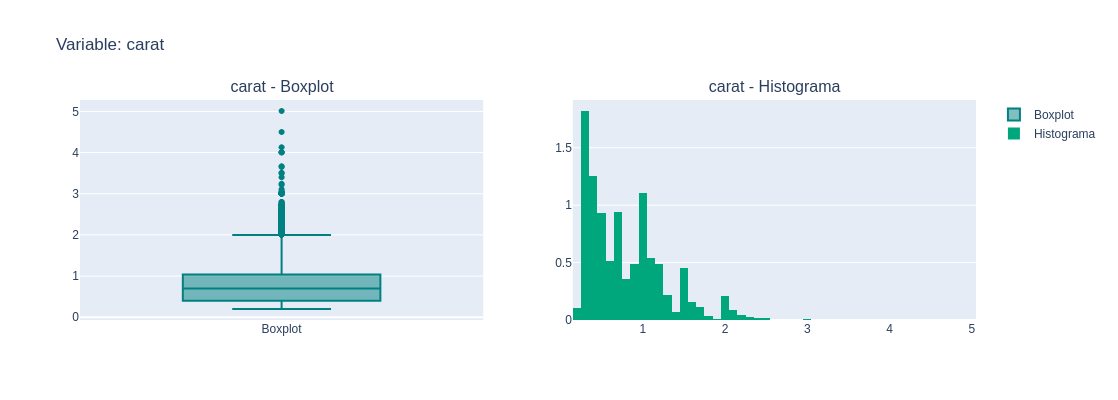

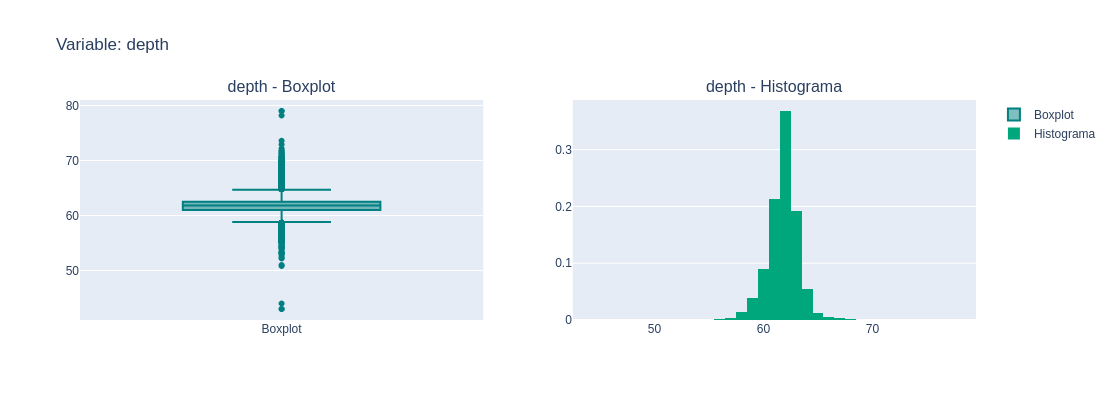

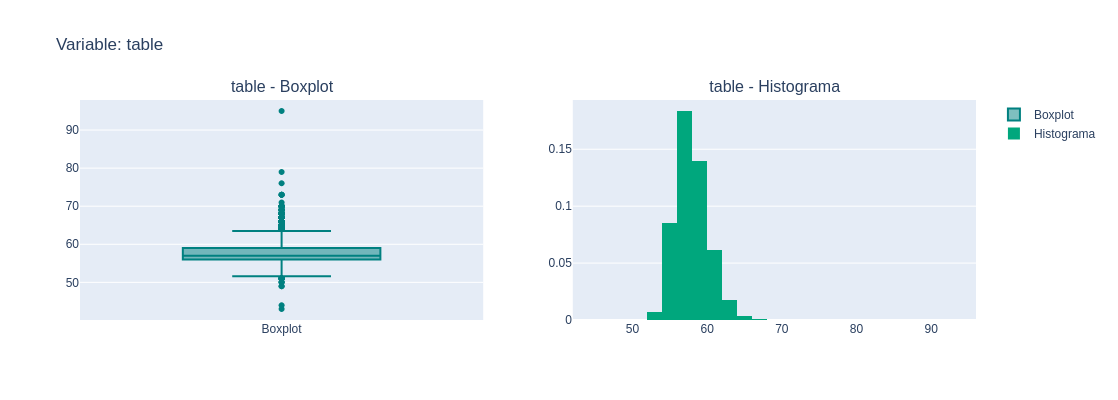

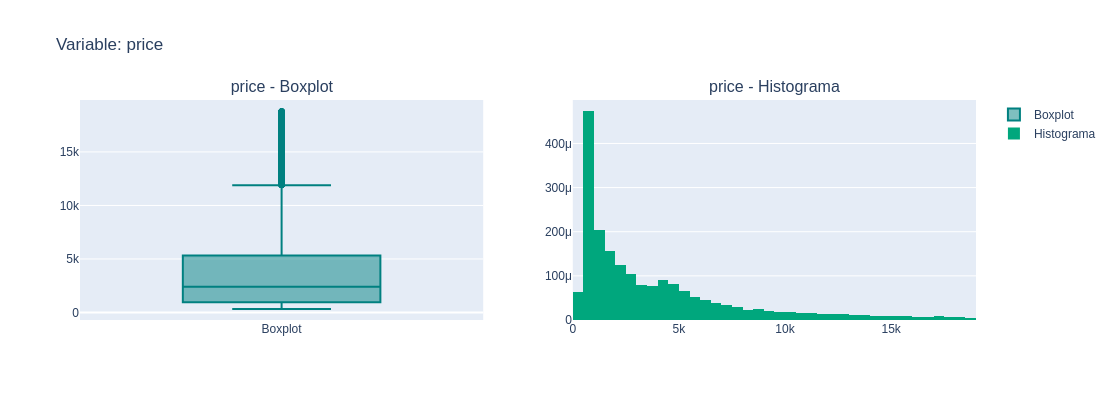

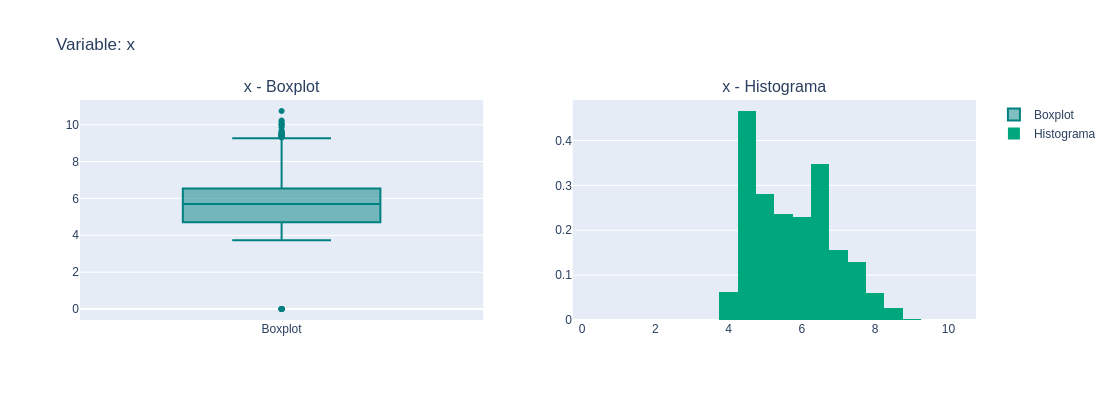

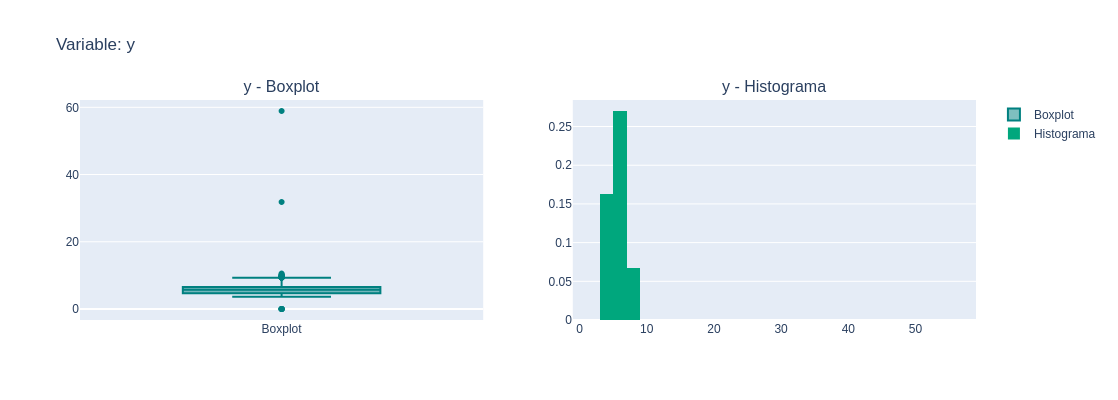

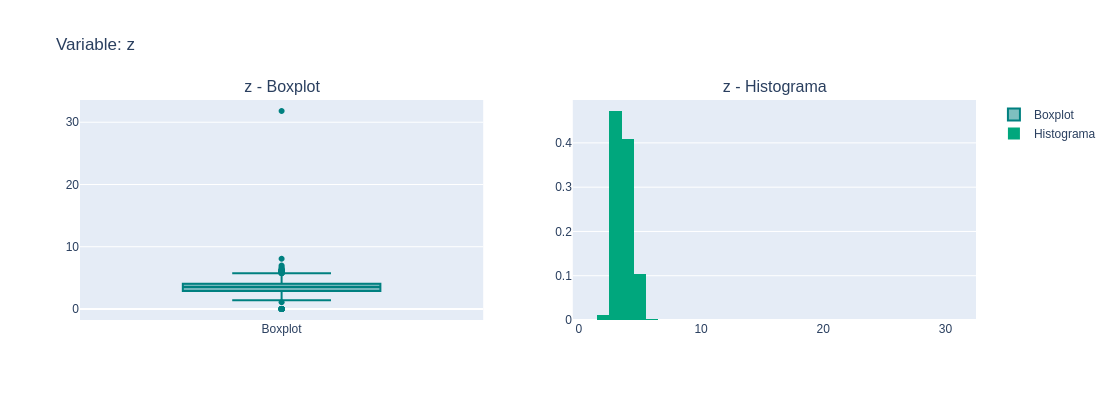

In [15]:
analisis_diamonds.plot_num()

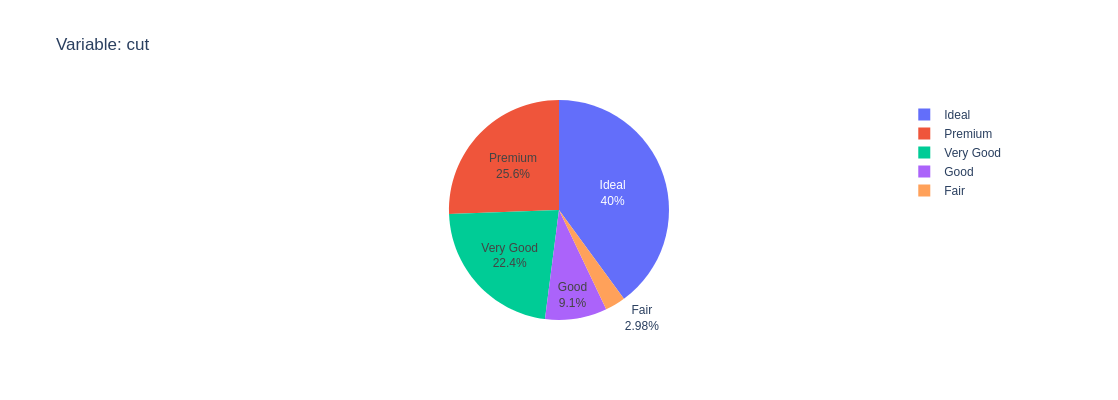

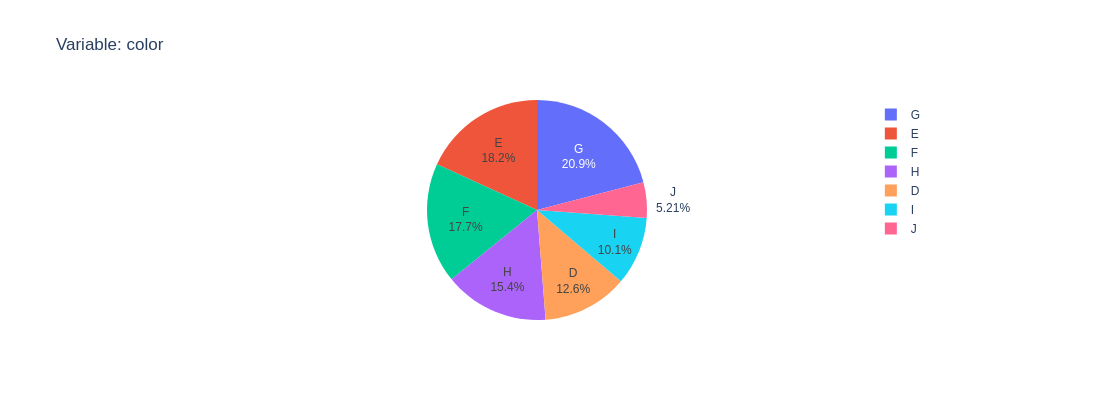

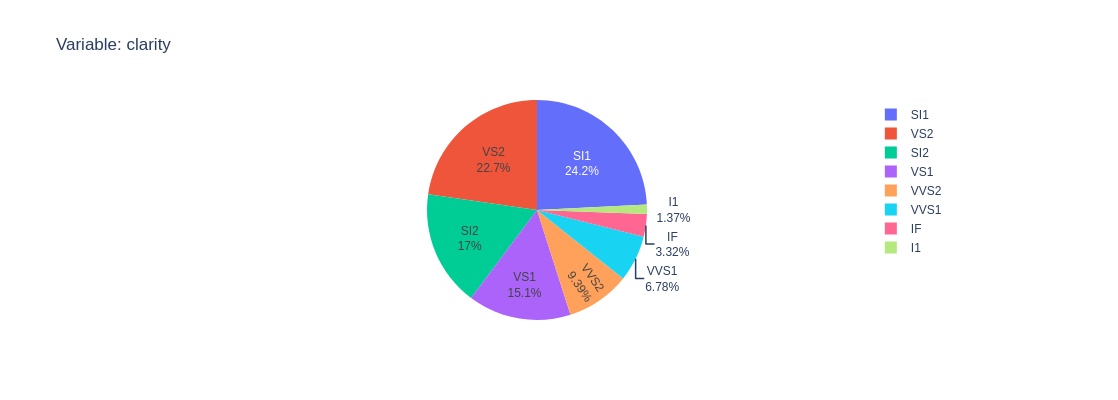

In [16]:
analisis_diamonds.plot_cat()

## Descripción del dataset

**Atributos de calidad** usados en gemología y explican buena parte del precio de un diamante.

* **cut (corte)**
  Calidad del tallado (proporciones, simetría y pulido). Escala típica, de mejor a peor:
  **Ideal/Excellent** → *Very Good* → *Good* → *Fair* → *Poor*.
  Un mejor corte maximiza el brillo y suele aumentar el precio (a igualdad de carat, color y claridad).

* **color**
  Grado de incoloro en diamantes blancos. Escala **D–Z** (GIA), donde **D** es totalmente incoloro (mejor) y conforme avanza hacia **Z** hay más tono amarillento/marrón (peor). En muchos datasets se restringe a **D–J**. Mejor color ⇒ mayor precio.

* **clarity (claridad)**
  Cantidad y visibilidad de inclusiones/imperfecciones. Escala típica (mejor → peor):
  **FL/IF** (Flawless/Internally Flawless) → **VVS1, VVS2** → **VS1, VS2** → **SI1, SI2** → **I1, I2, I3**.
  Más limpia ⇒ mayor precio.

* **carat**: peso del diamante (principal determinante de precio; relación no lineal).

* **depth, table**: proporciones geométricas (% de altura total y % de mesa).

* **x, y, z**: dimensiones en mm (largo, ancho, alto).

* **price**: precio en USD (objetivo).

In [17]:
# peor → mejor (J como menor, D como mayor)
color_order = ['J','I','H','G','F','E','D'] 
dtype = CategoricalDtype(categories=color_order, ordered=True)
clean_diamonds['color_cat'] = clean_diamonds['color'].astype(dtype)

In [18]:
# corte del diamante (peor → mejor)
cut_order = ['Fair','Good','Very Good','Premium','Ideal'] 
dtype = CategoricalDtype(categories=cut_order, ordered=True)
clean_diamonds['cut_cat'] = clean_diamonds['cut'].astype(dtype)

In [19]:
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
dtype = CategoricalDtype(categories=clarity_order, ordered=True)
clean_diamonds['clarity_cat'] = clean_diamonds['clarity'].astype(dtype)

## Descriptivos

In [20]:
percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

In [21]:
diamonds.describe(percentiles=percentiles).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
carat,53940.0,0.797940,0.474011,0.2,0.24,0.30,0.40,0.70,1.04,1.70,2.18,5.01
depth,53940.0,61.749405,1.432621,43.0,57.90,59.30,61.00,61.80,62.50,63.80,65.60,79.00
table,53940.0,57.457184,2.234491,43.0,53.00,54.00,56.00,57.00,59.00,61.00,64.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,429.00,544.00,950.00,2401.00,5324.25,13107.10,17378.22,18823.00
x,53940.0,5.731157,1.121761,0.0,4.02,4.29,4.71,5.70,6.54,7.66,8.36,10.74
y,53940.0,5.734526,1.142135,0.0,4.04,4.30,4.72,5.71,6.54,7.65,8.34,58.90
z,53940.0,3.538734,0.705699,0.0,2.48,2.65,2.91,3.53,4.04,4.73,5.15,31.80


## Análisis Descriptivo

* No se observan valores ausentes en el dataset.

* Las variables categóricas son variables ordinales ya que en realidad los valores si representan una peor o mejor calificación del atributo del diamante del que se esté hablando. Por otra parte, la mayoría de las categorías tienen una proporción entre un rango del 15% al 20% por lo que no están altamente desproporcionadas, a excepción del valor *Ideal* en la variable **cut** con una proporción cerca del 40% de los registros.

* Las variables continuas como x, y, z tienen pocos valores atípicos a diferencia del resto. Por ejemplo, se puede observar de los descriptivos y gráficos de caja que los valores extremos del peso y el precio del diamante se alejan más de la media y la mediana, hablándonos de una mayor dispersión de los valores.

Vamos aplicar el método de Insolation Forest para detectar estos valores atípicos y así poderlos remover del dataset.

## Valores Atípicos

In [22]:
diamonds_outliers = detect_outliers_iforest(diamonds[num_cols])

In [23]:
diamonds_outliers

,carat,depth,table,price,x,y,z
2,0.23,56.9,65.0,327,4.05,4.07,2.31
14,0.20,60.2,62.0,345,3.79,3.75,2.27
54,0.22,59.3,62.0,404,3.91,3.88,2.31
13002,2.14,69.4,57.0,5405,7.74,7.70,5.36
13029,0.23,58.1,63.0,600,4.08,4.04,2.36
...,...,...,...,...,...,...,...
37598,0.23,59.0,63.0,485,3.98,4.05,2.37
38278,0.21,59.1,62.0,386,3.89,3.86,2.29
40614,0.23,56.3,62.0,498,4.10,4.11,2.31
52860,0.50,79.0,73.0,2579,5.21,5.18,4.09


In [24]:
ratio = diamonds_outliers.shape[0]/diamonds.shape[0]
print(f'{ratio:.2%}')

1.00%


Encontramos 540 valores atípicos los cuales representan el 1% de nuestro dataset crudo, vamos a eliminar dichos registros.

In [25]:
clean_diamonds.drop(index=diamonds_outliers.index, inplace=True)

In [26]:
clean_diamonds.drop(columns=['cut','color','clarity'], inplace=True)

## Codificación de Variables Ordinales

In [49]:
y = clean_diamonds.loc[:, "price"]
X = clean_diamonds.loc[:, [x for x in clean_diamonds.columns if x != 'price']]

In [50]:
print(X.columns.tolist())

['carat', 'depth', 'table', 'x', 'y', 'z', 'color_cat', 'cut_cat', 'clarity_cat']


In [51]:
num_cols  = ['carat', 'depth', 'table', 'x', 'y', 'z']
cat_cols  = ['cut_cat', 'color_cat', 'clarity_cat'] 

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

#Particion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1077)

In [64]:
print("num_cols", num_cols, end='\n\n')
print("X_train columns =", X_train.columns.tolist())

num_cols ['carat', 'depth', 'table', 'x', 'y', 'z']

X_train columns = ['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_cat_Good', 'cut_cat_Very Good', 'cut_cat_Premium', 'cut_cat_Ideal', 'color_cat_I', 'color_cat_H', 'color_cat_G', 'color_cat_F', 'color_cat_E', 'color_cat_D', 'clarity_cat_SI2', 'clarity_cat_SI1', 'clarity_cat_VS2', 'clarity_cat_VS1', 'clarity_cat_VVS2', 'clarity_cat_VVS1', 'clarity_cat_IF']


In [55]:
scaler = MinMaxScaler()

In [56]:
scaler.fit(X_train, y_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [59]:
scaler.transform(X_train.loc[:, num_cols])

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- clarity_cat_IF
- clarity_cat_SI1
- clarity_cat_SI2
- clarity_cat_VS1
- clarity_cat_VS2
- ...


In [57]:
help(scaler.fit)

Help on method fit in module sklearn.preprocessing._data:

fit(X, y=None) method of sklearn.preprocessing._data.MinMaxScaler instance
    Compute the minimum and maximum to be used for later scaling.
    
    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        The data used to compute the per-feature minimum and maximum
        used for later scaling along the features axis.
    
    y : None
        Ignored.
    
    Returns
    -------
    self : object
        Fitted scaler.



In [54]:
dir(MinMaxScaler)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_reset',
 '_sklearn_auto_wrap_output_keys',
 '_validate_params',
 'fit',
 'fit_transform',
 'get_feature_names_out',
 'get_metadata_routing',
 'get_params',
 'inverse_transform',
 'partial_fit',
 'set_output

In [ ]:
pre = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols)
    ],
    remainder='drop'
)

model = Pipeline([('pre', pre)])

model.fit(X_train, y_train)

X_train.loc[:, num_cols] = model.transform(X_train.loc[:, num_cols])
X_test.loc[:, num_cols] = model.transform(X_test.loc[:, num_cols])

## Regresión Ordinaria

In [41]:
class Regresion:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        
        self.model = None
        self.y_fitted = None
        self.y_pred = None

    #Ajustamos el modelo
    def fit_reg(self):
        self.model = LinearRegression(fit_intercept=True)
        self.model.fit(self.X_train, self.y_train)
        
        #Calculamos predicciones
        self.y_fitted = self.model.predict(self.X_train)
        self.y_pred = self.model.predict(self.X_test)
        return self.model

    #Coeficientes del modelo
    def coefs(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
            
        cfs = [self.model.intercept_]
        cfs.extend(list(self.model.coef_))
        coef_names = ["intercept"] + list(self.X_train.columns)

        dt = {"Vars": coef_names, "Coefs": cfs}
        df_coefs = pd.DataFrame(dt)
        
        return df_coefs

    #Validacion cruzada
    def cross_values(self, cv=4):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
        
        cv_score = cross_val_score(
            estimator=self.model,
            X=self.X_train,
            y=self.y_train,
            cv=cv,
            n_jobs=-1,
            scoring="r2"
        )
        cv_values = {
            "media": np.round(np.mean(cv_score),3),
            "mediana": np.round(np.median(cv_score),3),
            "desv. est": np.round(np.std(cv_score, ddof=1),3)
        }
        return cv_values

    #Metricas de desempeño
    def performance(self):
        if self.y_fitted is None or self.y_pred is None:
            raise ValueError("Primero ajusta el modelo con fit_reg() para calcular predicciones")
        
        r2_train = np.round(r2_score(self.y_train, self.y_fitted), 3)
        r2_test  = np.round(r2_score(self.y_test, self.y_pred), 3)

        rmse_train = np.round(root_mean_squared_error(self.y_train, self.y_fitted), 3)
        rmse_test  = np.round(root_mean_squared_error(self.y_test, self.y_pred), 3)

        mae_train = np.round(mean_absolute_error(self.y_train, self.y_fitted), 3)
        mae_test  = np.round(mean_absolute_error(self.y_test, self.y_pred), 3)

        mape_train = np.round(mean_absolute_percentage_error(self.y_train, self.y_fitted), 3)
        mape_test  = np.round(mean_absolute_percentage_error(self.y_test, self.y_pred), 3)

        perform = {
            "Metrica": [
                "R2_train", "R2_test",
                "rmse_train", "rmse_test",
                "mae_train", "mae_test",
                "mape_train", "mape_test"
            ],
            "Valor": [
                r2_train, r2_test,
                rmse_train, rmse_test,
                mae_train, mae_test,
                mape_train, mape_test
            ]
        }
        return pd.DataFrame(perform)

In [42]:
#Instanciamos el modelo
lmodel = Regresion(X_train, X_test, y_train, y_test)

In [43]:
#Entrenamos y ajustamos
lmodel.fit_reg()

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(37380, 23) (37380,) (16020, 23) (16020,)


In [45]:
#Coeficientes del modelo
lmodel.coefs()

,Vars,Coefs
0,intercept,2376.250894
1,carat,28888.599231
2,depth,-2880.112428
3,table,-1147.319530
4,x,-13938.382365
5,y,-2427.697878
6,z,-1477.082768
7,cut_cat_Good,506.875781
8,cut_cat_Very Good,647.246305
9,cut_cat_Premium,691.648928


In [46]:
#Validación cruzada
lmodel.cross_values()

{'media': 0.925, 'mediana': 0.924, 'desv. est': 0.002}

In [47]:
#Performance 
lmodel.performance()

,Metrica,Valor
0,R2_train,0.926
1,R2_test,0.921
2,rmse_train,1044.025
3,rmse_test,1072.735
4,mae_train,697.677
5,mae_test,702.338
6,mape_train,0.378
7,mape_test,0.385


In [ ]:
def unscaled_X(serie: pd.Series):
    

In [48]:
dir(model)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_is_fitted__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_can_fit_transform',
 '_can_inverse_transform',
 '_can_transform',
 '_check_method_params',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_final_estimator',
 '_fit',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_for_step',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params',
 '_get_params_html',
 '_html_repr',
 '_iter',
 '_log

In [292]:
## Propuesto

class Regresion:
    def __init__(self, X_train, X_test, y_train, y_test,
                 scaler=None, num_cols=None):
        """
        X_train, X_test: DataFrames (con las columnas en el orden final usado al entrenar)
        y_train, y_test: Series o arrays 1-D (si vienen como (n,1), se aplastan a 1-D)
        scaler: MinMaxScaler ajustado con X_train[num_cols] (opcional; solo si quieres betas en escala original)
        num_cols: lista de columnas numéricas que fueron escaladas (opcional; para coefs_unscaled_minmax)
        """
        self.X_train = X_train
        self.X_test  = X_test
        # asegurar 1-D
        self.y_train = np.ravel(y_train)
        self.y_test  = np.ravel(y_test)

        self.scaler   = scaler
        self.num_cols = num_cols if num_cols is not None else []

        self.model    = None
        self.y_fitted = None
        self.y_pred   = None

    # 1) Ajustar el modelo
    def fit_reg(self):
        self.model = LinearRegression(fit_intercept=True)
        self.model.fit(self.X_train, self.y_train)
        # predicciones
        self.y_fitted = self.model.predict(self.X_train)
        self.y_pred   = self.model.predict(self.X_test)
        return self.model

    # 2) Coeficientes (escala tal cual se entrenó)
    def coefs(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
        b0    = float(np.atleast_1d(self.model.intercept_)[0])
        betas = np.ravel(self.model.coef_)  # (p,)

        coef_names = ["intercept"] + list(self.X_train.columns)
        cfs = [b0] + betas.tolist()

        return pd.DataFrame({"Vars": coef_names, "Coefs": cfs})

    # 3) Coeficientes reconvertidos a escala original (solo numéricas, MinMaxScaler)
    def coefs_unscaled_minmax(self):
        """
        Requiere self.scaler (MinMaxScaler ajustado con train) y self.num_cols.
        Las dummies/categóricas se dejan igual (no se escalaron).
        """
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
        if self.scaler is None or not self.num_cols:
            raise ValueError("Para desescalar, provee scaler=MinMaxScaler y num_cols=[...].")

        b0_esc  = float(np.atleast_1d(self.model.intercept_)[0])
        beta_sc = pd.Series(np.ravel(self.model.coef_), index=self.X_train.columns, name="beta_scaled")

        # parámetros del MinMax usados en train (en el mismo orden de num_cols)
        mins   = pd.Series(self.scaler.data_min_, index=self.num_cols)
        ranges = pd.Series(self.scaler.data_max_ - self.scaler.data_min_, index=self.num_cols)

        # iniciar como iguales
        beta_orig = beta_sc.copy()

        # desescalar SOLO las numéricas: beta_orig = beta_scaled / (max - min)
        for col in self.num_cols:
            if col in beta_orig.index:
                beta_orig.loc[col] = beta_sc.loc[col] / ranges.loc[col]

        # intercepto original:
        # b0_orig = b0_scaled + sum( (min_j / (max_j - min_j)) * beta_scaled_j ) para j en num_cols
        shift = (mins / ranges * beta_sc.reindex(self.num_cols)).sum()
        b0_orig = b0_esc + float(shift)

        out = pd.DataFrame({
            "Vars": ["intercept"] + list(self.X_train.columns),
            "beta_scaled": [b0_esc] + beta_sc.tolist(),
            "beta_orig":   [b0_orig] + beta_orig.tolist()
        })
        return out

    # 4) Gráfico y_test vs y_pred con diagonal y métricas
    def plot_pred_vs_actual(self, title="Predicción vs Observado"):
        if self.y_pred is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")

        y_true = self.y_test
        y_hat  = self.y_pred

        rmse = mean_squared_error(y_true, y_hat, squared=False)
        r2   = r2_score(y_true, y_hat)

        vmin = np.min([y_true.min(), y_hat.min()])
        vmax = np.max([y_true.max(), y_hat.max()])

        plt.figure(figsize=(6,6))
        plt.scatter(y_true, y_hat, alpha=0.5)
        plt.plot([vmin, vmax], [vmin, vmax], lw=2)  # diagonal y=x
        plt.title(f"{title}\nRMSE={rmse:.2f} | R²={r2:.3f}")
        plt.xlabel("y observada (test)")
        plt.ylabel("y predicha")
        plt.xlim(vmin, vmax)
        plt.ylim(vmin, vmax)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.grid(True, alpha=0.3)
        plt.show()


In [286]:
# supón que ya tienes:
# X_train, X_test, y_train, y_test, scaler_minmax (ajustado con X_train[num_cols]), num_cols

lmodel = Regresion(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    scaler=scaler_minmax,      # si NO quieres desescalar betas, puedes pasar None
    num_cols=num_cols          # ['carat','depth','table','x','y','z'] por ejemplo
)

lmodel.fit_reg()

# 1) Betas tal cual se entrenó (numéricas en escala MinMax; dummies sin escala)
betas_scaled = lmodel.coefs()
display(betas_scaled)

# 2) Betas reconvertidos a escala original (solo numéricas cambian)
betas_unscaled = lmodel.coefs_unscaled_minmax()
display(betas_unscaled)

# 3) Gráfico predicho vs observado
lmodel.plot_pred_vs_actual("Diamonds — Linear Regression")


NameError: name 'scaler_minmax' is not defined

### Propuesta

In [290]:
#from sklearn.preprocessing import MinMaxScaler

# ----- 1) Definir columnas -----
num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
cat_cols = ['cut_cat', 'color_cat', 'clarity_cat']   # tus categóricas ya ordenadas

# y como Serie 1-D
y = clean_diamonds['price']                 # importante: Serie, no DataFrame
X = clean_diamonds.drop(columns=['price'])

# ----- 2) Dummies (k-1) fuera del pipeline -----
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# ----- 3) Split antes de escalar -----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1077
)

# ----- 4) Escalar SOLO las numéricas: fit en train, transform en train y test -----
scaler = MinMaxScaler()
scaler.fit(X_train.loc[:, num_cols])                      # <- solo con TRAIN (y solo numéricas)

X_train = X_train.copy()
X_test  = X_test.copy()
X_train.loc[:, num_cols] = scaler.transform(X_train.loc[:, num_cols])
X_test.loc[:,  num_cols] = scaler.transform(X_test.loc[:,  num_cols])

# Hasta aquí: X_train y X_test ya están listos para tu clase Regresion


In [296]:
# Instanciar y entrenar
lmodel = Regresion(X_train, X_test, y_train, y_test)
lmodel.fit_reg()

# Ver coeficientes (en la escala entrenada: numéricas en MinMax, dummies sin escala)
df_betas = lmodel.coefs()
display(df_betas)

# Métricas/plot si ya tienes esos métodos
perf = lmodel.performance()     # si tienes ese método
display(perf)


,Vars,Coefs
0,intercept,2376.250894
1,carat,28888.599231
2,depth,-2880.112428
3,table,-1147.319530
4,x,-13938.382365
5,y,-2427.697878
6,z,-1477.082768
7,cut_cat_Good,506.875781
8,cut_cat_Very Good,647.246305
9,cut_cat_Premium,691.648928


,Metrica,Valor
0,R2_train,0.926
1,R2_test,0.921
2,rmse_train,1044.025
3,rmse_test,1072.735
4,mae_train,697.677
5,mae_test,702.338
6,mape_train,0.378
7,mape_test,0.385


In [300]:
# df_betas tiene 'Vars' y 'Coefs' (intercept + columnas)
coef_df = df_betas.copy()

# --- intercepto y betas (forma robusta) ---
b0_series = coef_df.loc[coef_df['Vars'] == 'intercept', 'Coefs']
b0_esc = float(b0_series.iloc[0])        # <-- en vez de float(Series)

# betas en el mismo orden de X_train
beta_sc = (coef_df.set_index('Vars')
                    .loc[X_train.columns, 'Coefs']
                    .astype(float))

# --- desescalar: solo numéricas cambian ---
mins   = pd.Series(scaler.data_min_, index=num_cols)
ranges = pd.Series(scaler.data_max_ - scaler.data_min_, index=num_cols)

# evitar división por cero (por si alguna numérica quedó constante)
ranges = ranges.replace(0, np.nan)

beta_orig = beta_sc.copy()
for col in num_cols:
    if col in beta_orig.index:
        beta_orig.loc[col] = beta_sc.loc[col] / ranges.loc[col]

# dummies: igual que escalado
shift = (mins / ranges * beta_sc.reindex(num_cols)).sum(min_count=1)
b0_orig = b0_esc + float(shift) if pd.notna(shift) else b0_esc

betas_final = pd.DataFrame({
    'Vars': ['intercept'] + list(beta_orig.index),
    'beta_scaled': [b0_esc] + beta_sc.tolist(),
    'beta_orig':   [b0_orig] + beta_orig.tolist()
})

display(betas_final)

,Vars,beta_scaled,beta_orig
0,intercept,2376.250894,-450.469595
1,carat,28888.599231,12954.528803
2,depth,-2880.112428,-94.121321
3,table,-1147.319530,-31.869987
4,x,-13938.382365,-1620.742136
5,y,-2427.697878,-41.217281
6,z,-1477.082768,-46.449144
7,cut_cat_Good,506.875781,506.875781
8,cut_cat_Very Good,647.246305,647.246305
9,cut_cat_Premium,691.648928,691.648928


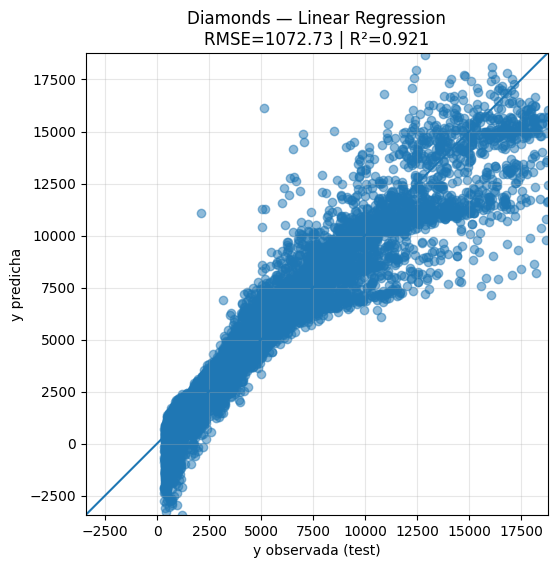

In [301]:
#import matplotlib.pyplot as plt
#from sklearn.metrics import mean_squared_error, r2_score

def plot_pred_vs_actual(y_true, y_pred, title="Predicción vs Observado"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) #, squared=False)
    r2   = r2_score(y_true, y_pred)
    vmin = min(np.min(y_true), np.min(y_pred))
    vmax = max(np.max(y_true), np.max(y_pred))

    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([vmin, vmax], [vmin, vmax])  # diagonal ideal
    plt.title(f"{title}\nRMSE={rmse:.2f} | R²={r2:.3f}")
    plt.xlabel("y observada (test)")
    plt.ylabel("y predicha")
    plt.xlim(vmin, vmax); plt.ylim(vmin, vmax)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(alpha=0.3)
    plt.show()

plot_pred_vs_actual(y_test, lmodel.y_pred, "Diamonds — Linear Regression")
